In [1]:
%pip install -q langgraph==0.3.31 
%pip install -q langchain-ibm==0.3.10
%pip install -q langchain==0.3.23
%pip install -q langchain_community==0.3.21 
%pip install -q pygraphviz==1.14

Note: you may need to restart the kernel to use updated packages.  DEPRECATION: Building 'ibm-cos-sdk' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'ibm-cos-sdk'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  DEPRECATION: Building 'ibm-cos-sdk-core' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'ibm-cos-sdk-core'. Discussion can be found at https://github.com/pypa/pip/issue

In [1]:
from langchain_ibm import ChatWatsonx
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph import END, MessageGraph, StateGraph

from typing import List, Sequence
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

/opt/conda/lib/python3.12/site-packages/langgraph/checkpoint/base/__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer

In [2]:
llm = ChatWatsonx(
    model_id="ibm/granite-4-h-small",
    url="https://us-south.ml.cloud.ibm.com",
    project_id="skills-network"
)

In [3]:
generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a professional LinkedIn content assistant tasked with crafting engaging, insightful, and well-structured LinkedIn posts."
            " Generate the best LinkedIn post possible for the user's request."
            " If the user provides feedback or critique, respond with a refined version of your previous attempts, improving clarity, tone, or engagement as needed.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

In [4]:
generate_chain = generation_prompt | llm

In [5]:
reflection_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """You are a professional LinkedIn content strategist and thought leadership expert. Your task is to critically evaluate the given LinkedIn post and provide a comprehensive critique. Follow these guidelines:

        1. Assess the post’s overall quality, professionalism, and alignment with LinkedIn best practices.
        2. Evaluate the structure, tone, clarity, and readability of the post.
        3. Analyze the post’s potential for engagement (likes, comments, shares) and its effectiveness in building professional credibility.
        4. Consider the post’s relevance to the author’s industry, audience, or current trends.
        5. Examine the use of formatting (e.g., line breaks, bullet points), hashtags, mentions, and media (if any).
        6. Evaluate the effectiveness of any call-to-action or takeaway.

        Provide a detailed critique that includes:
        - A brief explanation of the post’s strengths and weaknesses.
        - Specific areas that could be improved.
        - Actionable suggestions for enhancing clarity, engagement, and professionalism.

        Your critique will be used to improve the post in the next revision step, so ensure your feedback is thoughtful, constructive, and practical.
        """
    ),
    MessagesPlaceholder(variable_name="messages")
])

In [6]:
reflect_chain = reflection_prompt | llm

In [7]:
from langgraph.graph import MessageGraph
from typing import List, Annotated, TypedDict
from langchain.schema import HumanMessage, AIMessage, SystemMessage

# Initialize a predefined MessageGraph
graph = MessageGraph()

In [8]:
def generation_node(state: Sequence[BaseMessage]) -> List[BaseMessage]:
    generated_post = generate_chain.invoke({"messages": state})
    return [AIMessage(content=generated_post.content)]

In [9]:
def reflection_node(messages: Sequence[BaseMessage]) -> List[BaseMessage]:
    res = reflect_chain.invoke({"messages": messages})  # Passes messages as input to reflect_chain
    return [HumanMessage(content=res.content)]  # Returns the refined message as HumanMessage for feedback

In [10]:
graph.add_node("generate", generation_node)

In [11]:
graph.add_node("reflect", reflection_node)

In [12]:
graph.add_edge("reflect", "generate")

In [13]:
graph.set_entry_point("generate")

In [14]:
def should_continue(state: List[BaseMessage]):
    print(state)
    print(len(state))
    print("----------------------------------------------------------------------")
    if len(state) > 6:
        return END
    return "reflect"

In [15]:
graph.add_conditional_edges("generate", should_continue)

In [16]:
workflow = graph.compile()

In [17]:
inputs = HumanMessage(content="""Write a linkedin post on getting a software developer job at IBM under 160 characters""")

In [18]:
response = workflow.invoke(inputs)

/opt/conda/lib/python3.12/site-packages/ibm_watsonx_ai/wml_resource.py:100: WatsonxAPIWarning: The value of 'max_tokens' for this model was set to value 1024
ID: unspecified_max_token
  warn(cls._build_warning_message(warning), WatsonxAPIWarning)

[HumanMessage(content='Write a linkedin post on getting a software developer job at IBM under 160 characters', additional_kwargs={}, response_metadata={}, id='6190e0fb-db04-44e9-8719-79d1d52ece2b'), AIMessage(content='🚀 Score Your Dream Dev Role at IBM! 💻️ 🔑️\n\nCraft a stellar resume, ace coding interviews, and showcase projects. Network with IBM professionals & apply early to land your dev dream job at IBM! 💪🔥️ #IBMCareers #SoftwareDev #TechInterviews', additional_kwargs={}, response_metadata={}, id='bd7168b1-0b7f-4f01-af6c-9a892dbada66')]
2
----------------------------------------------------------------------

/opt/conda/lib/python3.12/site-packages/ibm_watsonx_ai/wml_resource.py:100: WatsonxAPIWarning: The value of 'max_tokens' for this model was set to value 1024
ID: unspecified_max_token
  warn(cls._build_warning_message(warning), WatsonxAPIWarning)/opt/conda/lib/python3.12/site-packages/ibm_watsonx_ai/wml_resource.py:100: WatsonxAPIWarning: The value of 'max_tokens' for this model was set to value 1024
ID: unspecified_max_token
  warn(cls._build_warning_message(warning), WatsonxAPIWarning)

[HumanMessage(content='Write a linkedin post on getting a software developer job at IBM under 160 characters', additional_kwargs={}, response_metadata={}, id='6190e0fb-db04-44e9-8719-79d1d52ece2b'), AIMessage(content='🚀 Score Your Dream Dev Role at IBM! 💻️ 🔑️\n\nCraft a stellar resume, ace coding interviews, and showcase projects. Network with IBM professionals & apply early to land your dev dream job at IBM! 💪🔥️ #IBMCareers #SoftwareDev #TechInterviews', additional_kwargs={}, response_metadata={}, id='bd7168b1-0b7f-4f01-af6c-9a892dbada66'), HumanMessage(content='Critique:\n\nStrengths:\n1. The post is concise and stays within the 160-character limit.\n2. It uses relevant hashtags (#IBMCareers, #SoftwareDev, #TechInterviews) to increase visibility.\n3. The emojis used add a visual appeal and break up the text, making it more scannable.\n\nWeaknesses:\n1. The post lacks a clear call-to-action (CTA) or takeaway for the reader.\n2. The tone could be more engaging and professional to captu

/opt/conda/lib/python3.12/site-packages/ibm_watsonx_ai/wml_resource.py:100: WatsonxAPIWarning: The value of 'max_tokens' for this model was set to value 1024
ID: unspecified_max_token
  warn(cls._build_warning_message(warning), WatsonxAPIWarning)/opt/conda/lib/python3.12/site-packages/ibm_watsonx_ai/wml_resource.py:100: WatsonxAPIWarning: The value of 'max_tokens' for this model was set to value 1024
ID: unspecified_max_token
  warn(cls._build_warning_message(warning), WatsonxAPIWarning)

[HumanMessage(content='Write a linkedin post on getting a software developer job at IBM under 160 characters', additional_kwargs={}, response_metadata={}, id='6190e0fb-db04-44e9-8719-79d1d52ece2b'), AIMessage(content='🚀 Score Your Dream Dev Role at IBM! 💻️ 🔑️\n\nCraft a stellar resume, ace coding interviews, and showcase projects. Network with IBM professionals & apply early to land your dev dream job at IBM! 💪🔥️ #IBMCareers #SoftwareDev #TechInterviews', additional_kwargs={}, response_metadata={}, id='bd7168b1-0b7f-4f01-af6c-9a892dbada66'), HumanMessage(content='Critique:\n\nStrengths:\n1. The post is concise and stays within the 160-character limit.\n2. It uses relevant hashtags (#IBMCareers, #SoftwareDev, #TechInterviews) to increase visibility.\n3. The emojis used add a visual appeal and break up the text, making it more scannable.\n\nWeaknesses:\n1. The post lacks a clear call-to-action (CTA) or takeaway for the reader.\n2. The tone could be more engaging and professional to captu

/opt/conda/lib/python3.12/site-packages/ibm_watsonx_ai/wml_resource.py:100: WatsonxAPIWarning: The value of 'max_tokens' for this model was set to value 1024
ID: unspecified_max_token
  warn(cls._build_warning_message(warning), WatsonxAPIWarning)

[HumanMessage(content='Write a linkedin post on getting a software developer job at IBM under 160 characters', additional_kwargs={}, response_metadata={}, id='6190e0fb-db04-44e9-8719-79d1d52ece2b'), AIMessage(content='🚀 Score Your Dream Dev Role at IBM! 💻️ 🔑️\n\nCraft a stellar resume, ace coding interviews, and showcase projects. Network with IBM professionals & apply early to land your dev dream job at IBM! 💪🔥️ #IBMCareers #SoftwareDev #TechInterviews', additional_kwargs={}, response_metadata={}, id='bd7168b1-0b7f-4f01-af6c-9a892dbada66'), HumanMessage(content='Critique:\n\nStrengths:\n1. The post is concise and stays within the 160-character limit.\n2. It uses relevant hashtags (#IBMCareers, #SoftwareDev, #TechInterviews) to increase visibility.\n3. The emojis used add a visual appeal and break up the text, making it more scannable.\n\nWeaknesses:\n1. The post lacks a clear call-to-action (CTA) or takeaway for the reader.\n2. The tone could be more engaging and professional to captu

/opt/conda/lib/python3.12/site-packages/ibm_watsonx_ai/wml_resource.py:100: WatsonxAPIWarning: The value of 'max_tokens' for this model was set to value 1024
ID: unspecified_max_token
  warn(cls._build_warning_message(warning), WatsonxAPIWarning)

In [19]:
response[1].content

'🚀 Score Your Dream Dev Role at IBM! 💻️ 🔑️\n\nCraft a stellar resume, ace coding interviews, and showcase projects. Network with IBM professionals & apply early to land your dev dream job at IBM! 💪🔥️ #IBMCareers #SoftwareDev #TechInterviews'

In [20]:
response[2].content

'Critique:\n\nStrengths:\n1. The post is concise and stays within the 160-character limit.\n2. It uses relevant hashtags (#IBMCareers, #SoftwareDev, #TechInterviews) to increase visibility.\n3. The emojis used add a visual appeal and break up the text, making it more scannable.\n\nWeaknesses:\n1. The post lacks a clear call-to-action (CTA) or takeaway for the reader.\n2. The tone could be more engaging and professional to capture the attention of the target audience.\n3. The post doesn\'t highlight any specific skills or qualifications that would be valuable for a software developer role at IBM.\n\nAreas for Improvement:\n1. Include a strong CTA to encourage readers to take action (e.g., visit a specific website, read a blog post, or connect on LinkedIn).\n2. Use a more professional and engaging tone to connect with the reader and establish credibility.\n3. Highlight specific skills, qualifications, or tips that are relevant to landing a software developer job at IBM.\n\nActionable Sug

In [21]:
response[-1].content

'🚀 Supercharge Your IBM Developer Career! 🚀️💻️\n\nAce coding interviews, showcase projects, & network with IBM pros. Boost your resume with Java, Python & cloud tech mastery. Kickstart your IBM software dev journey today! 🌟️🔑️ #IBMCareers #SoftwareDev'

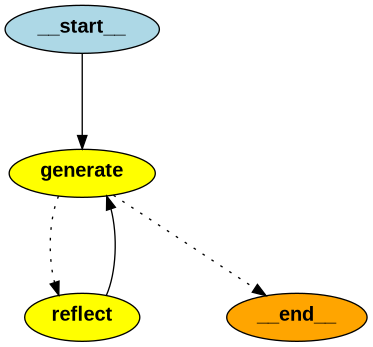

In [22]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_png()))